### This notebook will examine how much similar are L2reg and NNLS models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.summarize as ccs
import cortico_cereb_connectivity.evaluation as ev
from mpl_toolkits.axes_grid1 import make_axes_locatable
import Functional_Fusion.atlas_map as am
import SUITPy as suit

In [4]:
def vox_corr(X, Y):
    """Compute the correlation between two matrices X and Y along the second axis."""
    X = X - np.mean(X, axis=1, keepdims=True)
    Y = Y - np.mean(Y, axis=1, keepdims=True)
    corr = np.sum(X * Y, axis=1) / (np.sqrt(np.sum(X**2, axis=1)) * np.sqrt(np.sum(Y**2, axis=1)))
    return corr

In [5]:
def scatter_plot_with_marginals(x, y, t=None, title='', R=0, margin=False, iflog=True):
    if t is not None:
        ax = plt.subplot(3, 3, t+1)
    else:
        t = 6
        ax = plt.gca()
    ax.scatter(x, y, s=4, alpha=0.1, color='black')

    if margin:
        divider = make_axes_locatable(ax)
        ax_histx = divider.append_axes("top", size="25%", pad=0.1, sharex=ax)
        ax_histy = divider.append_axes("right", size="25%", pad=0.1, sharey=ax)

        ax_histx.hist(x, bins=50, color='gray', alpha=0.6, log=iflog)
        ax_histy.hist(y, bins=50, orientation='horizontal', color='gray', alpha=0.6, log=iflog)

        # tidy up marginal axes
        ax_histx.xaxis.set_tick_params(labelbottom=False)
        ax_histy.yaxis.set_tick_params(labelleft=False)

        # keep limits consistent
        ax_histx.set_xlim(ax.get_xlim())
        ax_histy.set_ylim(ax.get_ylim())
        ax_histx.set_title(title, pad=6)

    if R is not None:
        ax.text(0.05, 0.95, f'R={R:.2f}', transform=ax.transAxes, 
                verticalalignment='top', fontsize=10)

    if t>=6:
        ax.set_xlabel('NNLS coefficients')
    if t%3==0:
        ax.set_ylabel('L2reg coefficients')
    if not margin:
        ax.set_title(title)

#### Load global models

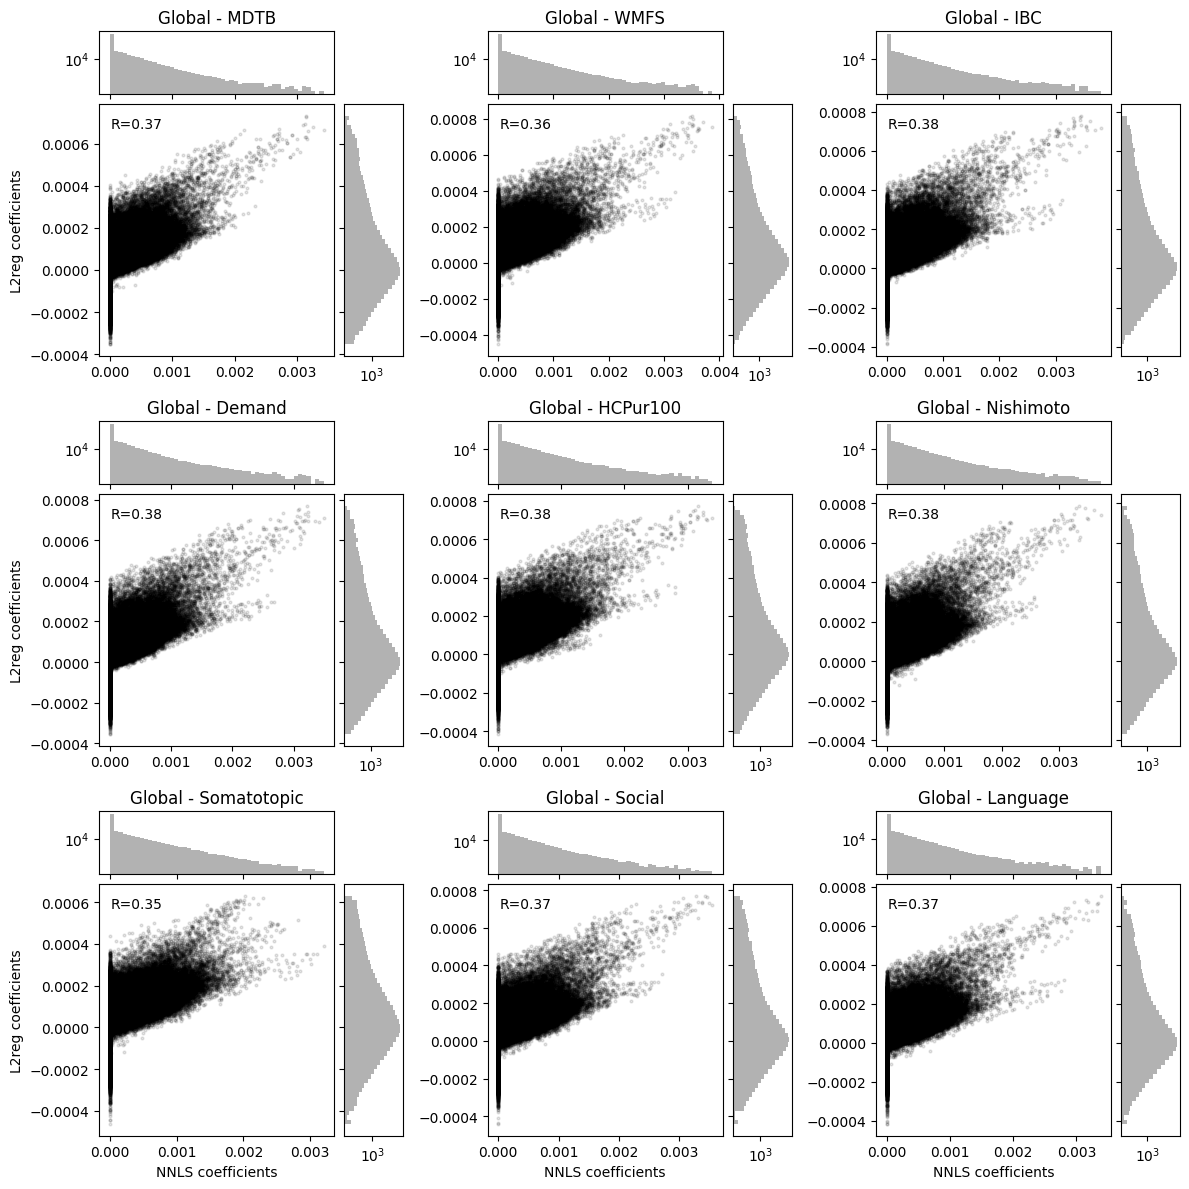

In [6]:
train_ds_list = gl.get_ldo_names()
eval_ds_list = gl.datasets

R_vox_list_global = []
plt.subplots(3, 3, figsize=(12, 12), tight_layout=True)#, sharex=True, sharey=True)
for t, (traindata, ev_ds) in enumerate(zip(train_ds_list, eval_ds_list)):
    model_NNLS, _ = ccs.get_model(traindata, 'Icosahedron1002', 'NNLS', "A0_global", cerebellum_atlas="MNISymC3", norm=True)
    model_L2reg, _ = ccs.get_model(traindata, 'Icosahedron1002', 'L2reg', "A2_global", cerebellum_atlas="MNISymC3", norm=True)

    R, R_vox = ev.calculate_R(model_NNLS.coef_.T, model_L2reg.coef_.T)
    R_vox_list_global.append(R_vox)
    scatter_plot_with_marginals(model_NNLS.coef_.flatten(), model_L2reg.coef_.flatten(), t, f'Global - {ev_ds}', R, margin=True)

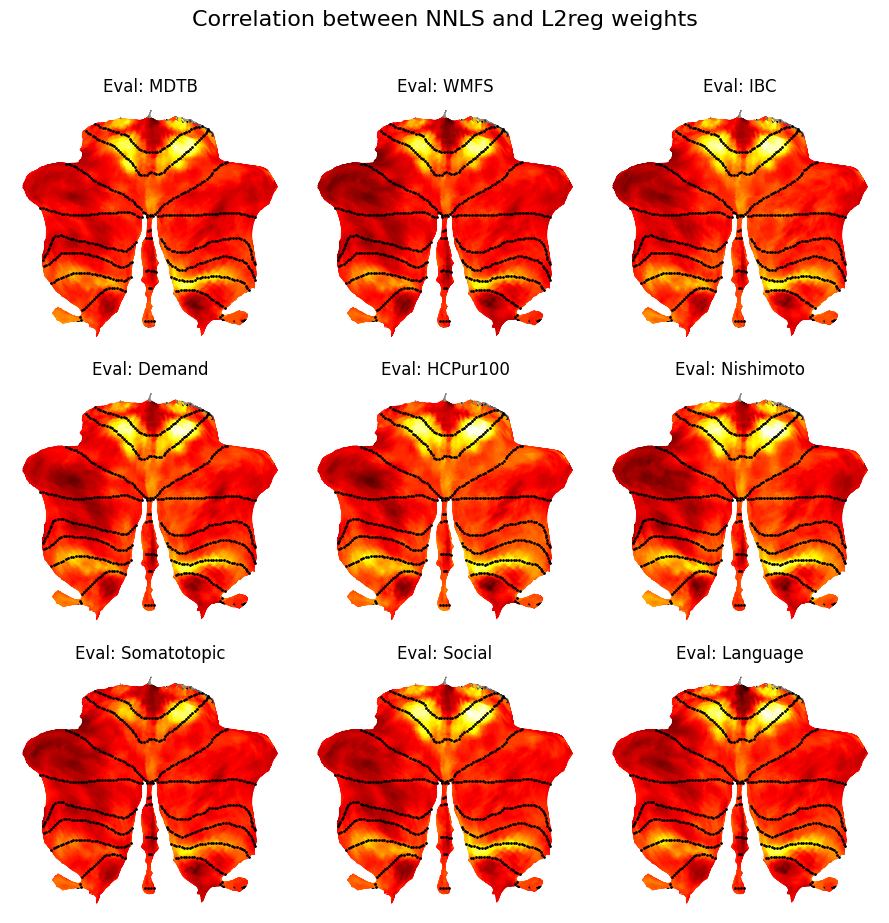

In [7]:
atlas, _ = am.get_atlas('MNISymC3')
plt.subplots(3, 3, figsize=(9, 9), tight_layout=True)
plt.suptitle('Correlation between NNLS and L2reg weights', y=1.02, fontsize=16)
for t, (eval_ds, R_vox) in enumerate(zip(eval_ds_list, R_vox_list_global)):
    R_vox_data = suit.vol_to_surf(atlas.data_to_nifti(R_vox), space='MNISymC')
    plt.subplot(3, 3, t+1)
    plt.title(f'Eval: {eval_ds_list[t]}')
    suit.flatmap.plot(R_vox_data, cmap='hot', new_figure=False, cscale=(0.2, 0.6))

### Global Global Model

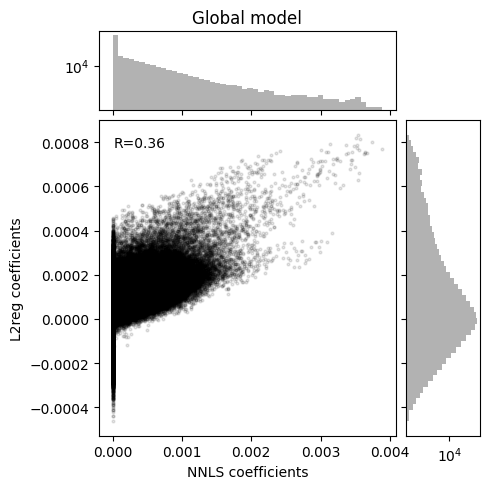

In [8]:
traindata = ''.join(gl.dscode)

plt.figure(figsize=(5, 5), tight_layout=True)
model_NNLS, _ = ccs.get_model(traindata, 'Icosahedron1002', 'NNLS', "A0_global", cerebellum_atlas="MNISymC3", norm=True)
model_L2reg, _ = ccs.get_model(traindata, 'Icosahedron1002', 'L2reg', "A2_global", cerebellum_atlas="MNISymC3", norm=True)

R, R_vox = ev.calculate_R(model_NNLS.coef_.T, model_L2reg.coef_.T)
scatter_plot_with_marginals(model_NNLS.coef_.flatten(), model_L2reg.coef_.flatten(), None, f'Global model', R, margin=True)

Prediction Correlation (R = 0.36 ± 0.06)


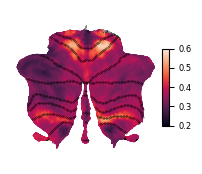

In [9]:
save_plot = False
atlas, _ = am.get_atlas('MNISymC3')

fig = plt.figure(figsize=(2.3,2))
suit.flatmap.plot(suit.vol_to_surf(atlas.data_to_nifti(R_vox), space='MNISymC'), 
                  cmap='rocket', new_figure=False, cscale=(.2, .6), colorbar=True, bordersize=0.5);
for cax in fig.axes:
    cax.tick_params(axis='both', labelsize=6, width=0.75);

print(f'Prediction Correlation (R = {np.array(R_vox).mean():.2f} ± {np.array(R_vox).std():.2f})');
if save_plot:
    plt.savefig(gl.fig_dir + "/fig02_c.pdf", dpi=300, bbox_inches='tight');

#### Conditional Distribution

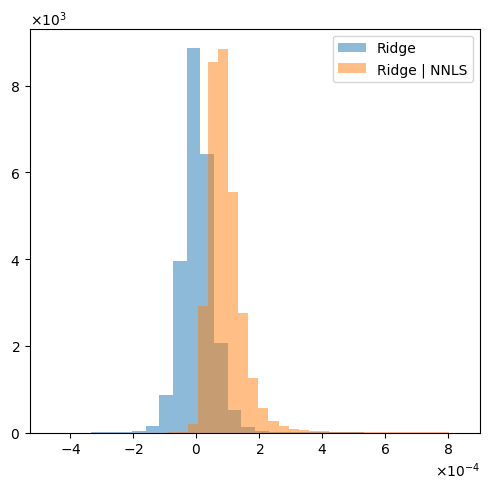

In [12]:
traindata = ''.join(gl.dscode)

plt.figure(figsize=(5, 5), tight_layout=True)
model_NNLS, _ = ccs.get_model(traindata, 'Icosahedron1002', 'NNLS', "A0_global", cerebellum_atlas="MNISymC3", norm=True)
model_L2reg, _ = ccs.get_model(traindata, 'Icosahedron1002', 'L2reg', "A2_global", cerebellum_atlas="MNISymC3", norm=True)

mask = model_NNLS.coef_ > 0
plt.hist(model_L2reg.coef_.flatten(), bins=30, alpha=0.5, label='Ridge', density=True)
plt.hist(model_L2reg.coef_[mask].flatten(), bins=30, alpha=0.5, label='Ridge | NNLS', density=True)
ax = plt.gca()
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
plt.legend();

In [13]:
print(f'Percent of positive weights conditional on NNLS: {np.nanmean(model_L2reg.coef_[mask] > 0) * 100:.1f}%')

Percent of positive weights conditional on NNLS: 99.6%


#### Masked Ridge

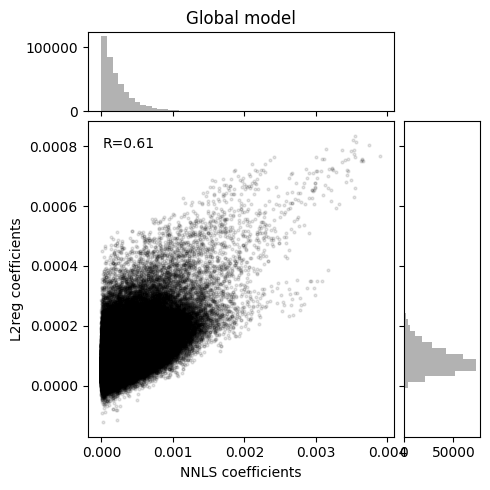

In [14]:
traindata = ''.join(gl.dscode)

plt.figure(figsize=(5, 5), tight_layout=True)
model_NNLS, _ = ccs.get_model(traindata, 'Icosahedron1002', 'NNLS', "A0_global", cerebellum_atlas="MNISymC3", norm=True)
model_L2reg, _ = ccs.get_model(traindata, 'Icosahedron1002', 'L2reg', "A2_global", cerebellum_atlas="MNISymC3", norm=True)

mask = model_NNLS.coef_ > 0
R = np.corrcoef(model_NNLS.coef_[mask].flatten(), model_L2reg.coef_[mask].flatten())[0, 1]
scatter_plot_with_marginals(model_NNLS.coef_[mask].flatten(), model_L2reg.coef_[mask].flatten(), None, f'Global model', R, margin=True, iflog=False)

#### Where do these negative weights go?

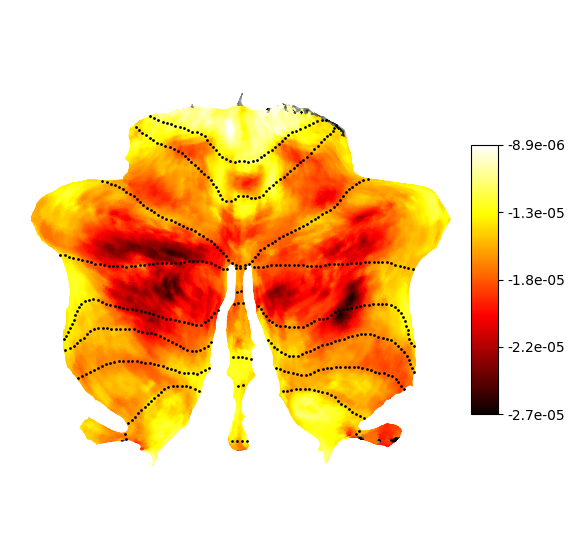

In [15]:
traindata = gl.traindata_string()
atlas, _ = am.get_atlas('MNISymC3')

model_L2reg, _ = ccs.get_model(traindata, 'Icosahedron1002', 'L2reg', "A2_global", cerebellum_atlas="MNISymC3", norm=True)
data = np.where(model_L2reg.coef_ < 0, model_L2reg.coef_, 0)
data2 = np.nanmean(data, axis=1)

vox_data = suit.vol_to_surf(atlas.data_to_nifti(data2), space='MNISymC')
suit.flatmap.plot(vox_data, cmap='hot', colorbar=True);